# 課題と解答例：3頂点の線形モデル

元Notebook：[42_love_dynamics_network.ipynb](../42_love_dynamics_network.ipynb)

課題と解答，必要な関数だけをまとめた独立実行用Notebookである．

## 課題

1. `chain_matrix(n, weight)` を作り，一方向の鎖 `node 1 -> ... -> node n` を表す隣接行列を返す．非正整数の頂点数や負の重みは拒否し，孤立した1頂点と重み0も試す．
2. `edge_table(A)` と `graph_from_A(A)` を作り，非対称な行列の非零要素と全矢印・重みを照合する．行列からグラフへ変換し，転置に注意して行列へ戻す `assert` を書く．
3. `stability_sweep(A, alpha, beta_values)` を作り，結合強度と最大固有値実部をDataFrameで返す．循環，鎖，$A=\begin{pmatrix}0&-1\\1&0\end{pmatrix}$ を比較する．臨界値が存在しない場合もそのまま報告する．
4. `chain_exact(alpha, beta, weight, times)` を作り，初期値 $(1,0,0)^\top$ の3頂点鎖の厳密解と数値解を照合する．基準の循環では $M\mathbf e_1$ を計算し，短時間の $x_3/t$ と $x_2/t^2$ の極限も確認する．
5. `network_metrics(A, alpha, beta, x0, times)` を作り，最大固有値実部，保存時刻での最大ノルム比，終了時ノルムを返す．3頂点の鎖と循環を，総辺重みがともに3となるようそろえて比較する．初期ノルムと時間窓も固定する．最大実部だけでは過渡応答を決められないことと，総重みをそろえても受け手ごとの入力は同一ではないことを考察する．

## 実行に必要な定義

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import expm

import networkx as nx

In [2]:
def square_matrix(matrix):
    raw = np.asarray(matrix)
    if np.iscomplexobj(raw):
        raise ValueError('This notebook uses real matrices.')
    matrix = np.asarray(raw, dtype=float)
    if (matrix.ndim != 2 or matrix.shape[0] != matrix.shape[1]
            or matrix.shape[0] == 0 or not np.all(np.isfinite(matrix))):
        raise ValueError('matrix must be a nonempty finite square matrix')
    return matrix


def linear_inputs(matrix, x0, times):
    matrix = square_matrix(matrix)
    if np.iscomplexobj(x0) or np.iscomplexobj(times):
        raise ValueError('states and times must be real')
    x0, times = np.asarray(x0, dtype=float), np.asarray(times, dtype=float)
    if x0.shape != (matrix.shape[0],) or not np.all(np.isfinite(x0)):
        raise ValueError('x0 must match the matrix dimension and be finite')
    if (times.ndim != 1 or len(times) < 2 or not np.all(np.isfinite(times))
            or np.any(np.diff(times) <= 0)):
        raise ValueError('times must contain at least two increasing finite values')
    return matrix, x0, times


def solve_linear(matrix, x0, times, rtol=1e-8, atol=1e-10):
    matrix, x0, times = linear_inputs(matrix, x0, times)
    if not (np.isfinite(rtol) and np.isfinite(atol) and rtol > 0 and atol > 0):
        raise ValueError('rtol and atol must be finite and positive')
    sol = solve_ivp(lambda t, x: matrix @ x, (times[0], times[-1]), x0,
                    t_eval=times, rtol=rtol, atol=atol)
    if not sol.success:
        raise RuntimeError(sol.message)
    if sol.y.shape != (len(x0), len(times)) or not np.all(np.isfinite(sol.y)):
        raise RuntimeError('incomplete or nonfinite solution')
    return sol


def linear_reference(matrix, x0, times):
    matrix, x0, times = linear_inputs(matrix, x0, times)
    result = np.column_stack([expm(matrix * (t - times[0])) @ x0 for t in times])
    if not np.all(np.isfinite(result)):
        raise RuntimeError('nonfinite matrix-exponential reference')
    return result

In [3]:
def network_matrix(A, alpha, beta):
    A = square_matrix(A)
    if not np.isfinite(alpha) or alpha <= 0:
        raise ValueError('alpha must be finite and positive')
    if not np.isfinite(beta) or beta < 0:
        raise ValueError('beta must be finite and nonnegative')
    return -alpha*np.eye(len(A)) + beta*A


def spectral_abscissa(M):
    return float(np.linalg.eigvals(square_matrix(M)).real.max())

## 課題の関数

鎖の規約は受け手が行，送り手が列である．負の辺の例は一般の安定性比較で扱い，鎖の生成関数自体は非負重みに限定する．

In [4]:
def chain_matrix(n, weight=1.0):
    if isinstance(n, (bool, np.bool_)) or not isinstance(n, (int, np.integer)) or n < 1:
        raise ValueError('n must be a positive integer')
    if not np.isfinite(weight) or weight < 0:
        raise ValueError('weight must be finite and nonnegative')
    A = np.zeros((n, n))
    for j in range(n-1):
        A[j+1, j] = weight
    return A


def edge_table(A):
    A = square_matrix(A)
    return pd.DataFrame([{'from': j, 'to': i, 'weight': A[i, j]}
                         for i in range(len(A)) for j in range(len(A)) if A[i, j] != 0],
                        columns=['from', 'to', 'weight'])


def graph_from_A(A):
    A = square_matrix(A)
    G = nx.DiGraph()
    G.add_nodes_from(range(len(A)))
    for row in edge_table(A).to_dict('records'):
        G.add_edge(int(row['from']), int(row['to']), weight=float(row['weight']))
    return G


def stability_sweep(A, alpha, beta_values):
    A = square_matrix(A)
    rows = []
    for beta in beta_values:
        M = network_matrix(A, alpha, beta)
        rows.append({'beta': beta, 'max_real': spectral_abscissa(M)})
    return pd.DataFrame(rows, columns=['beta', 'max_real'])


def chain_exact(alpha, beta, weight, times):
    A = chain_matrix(3, weight)
    M = network_matrix(A, alpha, beta)
    _, _, times = linear_inputs(M, [1., 0., 0.], times)
    s = times-times[0]
    return np.exp(-alpha*s)*np.array([np.ones_like(s), beta*weight*s, (beta*weight*s)**2/2])


def network_metrics(A, alpha, beta, x0, times):
    M = network_matrix(A, alpha, beta)
    M, x0, times = linear_inputs(M, x0, times)
    norm0 = np.linalg.norm(x0)
    if norm0 == 0:
        raise ValueError('gain requires a nonzero initial state')
    sol = solve_linear(M, x0, times)
    norms = np.linalg.norm(sol.y, axis=0)
    return {'max_real': spectral_abscissa(M),
            'sampled_peak_gain': float(norms.max()/norm0),
            'terminal_norm': float(norms[-1])}

## 鎖とグラフ変換の確認

孤立頂点も失わず，重みと向きを往復変換で確認する．転置した行列でも固有値が変わらないことを別に確認する．

In [5]:
A = np.array([[0., .8, 0.], [0., 0., 1.], [.5, 0., 0.]])
chain = chain_matrix(3)
print('chain =', chain, sep='\n')
print(edge_table(A).to_string(index=False))
G = graph_from_A(A)
np.testing.assert_allclose(nx.to_numpy_array(G, nodelist=range(3)).T, A)
assert set(G.edges()) == {(1, 0), (0, 2), (2, 1)}
assert len(graph_from_A(chain_matrix(1))) == 1
assert graph_from_A(chain_matrix(3, 0)).number_of_edges() == 0
np.testing.assert_allclose(np.sort_complex(np.linalg.eigvals(A)),
                           np.sort_complex(np.linalg.eigvals(A.T)))

chain =
[[0. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]]
 from  to  weight
    1   0     0.8
    2   1     1.0
    0   2     0.5


## 臨界値がある例とない例

循環の臨界値は $0.8/\sqrt[3]{0.4}$ である．鎖と符号付き回転行列では最大実部が常に $-0.8$ となる．後者のスペクトル半径は1でも最大実部は0であり，両者は代用できない．

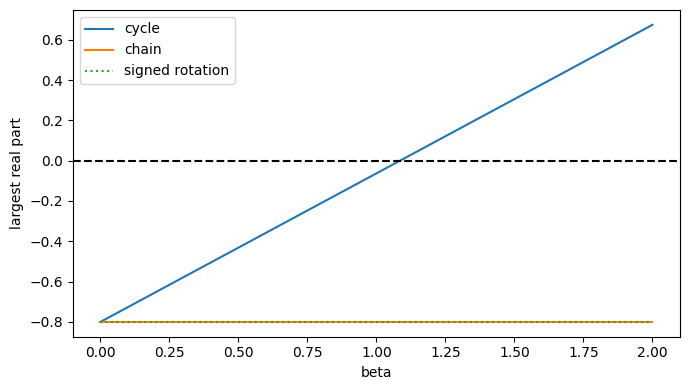

cycle critical beta: 1.0857670466379628


In [6]:
alpha = .8
betas = np.linspace(0, 2, 101)
rotation = np.array([[0., -1.], [1., 0.]])
fig, ax = plt.subplots(figsize=(7, 4))
for name, matrix in [('cycle', A), ('chain', chain), ('signed rotation', rotation)]:
    frame = stability_sweep(matrix, alpha, betas)
    ax.plot(frame.beta, frame.max_real, label=name, ls=':' if name == 'signed rotation' else '-')
    expected = -alpha+betas*np.cbrt(.4) if name == 'cycle' else -alpha
    np.testing.assert_allclose(frame.max_real, expected, atol=1e-14)
ax.axhline(0, color='black', ls='--')
ax.set(xlabel='beta', ylabel='largest real part'); ax.legend()
fig.tight_layout(); plt.show()
print('cycle critical beta:', alpha/np.cbrt(.4))

## 厳密解と初期微分の確認

鎖では $A^3=0$ により2次で級数が止まる．循環では $x_3/t\to0.5\beta$，$x_2/t^2\to0.25\beta^2$ を確認する．0を割らないよう正の小さな時刻を使い，初期時刻0を参照解の配列に含める．

In [7]:
times = np.linspace(0, 18, 501)
beta = 3.
exact = chain_exact(alpha, beta, 1., times)
sol = solve_linear(network_matrix(chain, alpha, beta), [1., 0., 0.], times)
print('chain max absolute error:', np.max(np.abs(sol.y-exact)))
np.testing.assert_allclose(sol.y, exact, atol=5e-8, rtol=1e-7)
beta = .6
M = network_matrix(A, alpha, beta)
np.testing.assert_allclose(M @ np.array([1., 0., 0.]), [-alpha, 0., .5*beta])
rows = []
for h in [1e-2, 1e-3, 1e-4]:
    end = linear_reference(M, [1., 0., 0.], [0., h])[:, -1]
    rows.append({'h': h, 'x3/h': end[2]/h, 'x2/h**2': end[1]/h**2})
print(pd.DataFrame(rows).to_string(index=False))
np.testing.assert_allclose([rows[-1]['x3/h'], rows[-1]['x2/h**2']],
                           [.5*beta, .25*beta**2], rtol=1e-3)

chain max absolute error: 9.576453408044472e-09
     h     x3/h  x2/h**2
0.0100 0.297610 0.089283
0.0010 0.299760 0.089928
0.0001 0.299976 0.089993


## 同じ総重みで比較する

循環の3辺を各1，鎖の2辺を各1.5とする．総和はどちらも3だが，受け手ごとの入力総量は同じではない．以下の実験は総重みをそろえた比較であり，構造だけを完全に分離した比較ではない．有限時間の最大値と長時間安定性を別々に報告する．

In [8]:
cycle_equal = np.array([[0., 1., 0.], [0., 0., 1.], [1., 0., 0.]])
chain_equal_total = chain_matrix(3, 1.5)
assert cycle_equal.sum() == chain_equal_total.sum() == 3
rows = []
for name, matrix in [('cycle', cycle_equal), ('chain', chain_equal_total)]:
    for strength in [.6, 1.0]:
        result = network_metrics(matrix, .8, strength, [1., 0., 0.], np.linspace(0, 20, 1001))
        rows.append(dict(network=name, beta=strength, total_weight=matrix.sum(), **result))
print(pd.DataFrame(rows).to_string(index=False))

network  beta  total_weight  max_real  sampled_peak_gain  terminal_norm
  cycle   0.6           3.0      -0.2           1.000000       0.010575
  cycle   1.0           3.0       0.2          31.522257      31.522257
  chain   0.6           3.0      -0.8           1.000000       0.000018
  chain   1.0           3.0      -0.8           1.111130       0.000051
